# 1. Importing Libraries and loading Dataset

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
# Importing ML Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
import warnings

In [6]:
warnings.filterwarnings('ignore')
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
data=pd.read_csv('/kaggle/input/restaurant-reviews/Restaurant_Reviews.tsv', sep='\t')

# 2.  EDA & Text Cleaning

In [8]:
data.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [9]:
data.shape

(1000, 2)

In [10]:
data.isnull().sum()

Review    0
Liked     0
dtype: int64

In [11]:
data['Liked'].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

In [12]:
# Adding Columns of char, word, and sent count
# No. of Characters column
data['char_count']=data['Review'].apply(len)
# No. of Words count column
data['word_count']=data['Review'].apply(lambda x :len(str(x).split()))
# No. of Sent count column
data['sent_count']=data['Review'].apply(lambda x:len(nltk.sent_tokenize(str(x))))

In [13]:
data.head()

,Review,Liked,char_count,word_count,sent_count
0,Wow... Loved this place.,1,24,4,2
1,Crust is not good.,0,18,4,1
2,Not tasty and the texture was just nasty.,0,41,8,1
3,Stopped by during the late May bank holiday of...,1,87,15,1
4,The selection on the menu was great and so wer...,1,59,12,1


In [14]:
# avg #char in positive reviews
data[data['Liked']==1]['char_count'].mean()

55.88

In [15]:
# avg #char in negative reviews
data[data['Liked']==0]['char_count'].mean()

60.75

In [16]:
data['Review'][1]

'Crust is not good.'

In [17]:
review=re.sub('[^a-zA-Z]',' ',data['Review'][1])

In [18]:
review=review.lower()

In [19]:
review=review.split()

In [20]:
review

['crust', 'is', 'not', 'good']

In [21]:
all_stopwords=stopwords.words('english')
all_stopwords.remove('not')

In [22]:
all_stopwords

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [23]:
review=[word for word in review if word not in set(all_stopwords)]

In [24]:
review

['crust', 'not', 'good']

In [25]:
custom_stopwords = {
    'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
    'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't",
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}
corpus=[]
ps = PorterStemmer()
stop_words=set(stopwords.words("english"))-custom_stopwords

for i in range(len(data)):
    review=re.sub('[^a-zA-Z]',' ',data['Review'][i])
    review=review.lower()
    review=review.split()
    review=[ps.stem(word) for word in review if word not in stop_words]
    review=" ".join(review)
    corpus.append(review)

In [26]:
data['processed_text']=corpus

In [27]:
data.head()

,Review,Liked,char_count,word_count,sent_count,processed_text
0,Wow... Loved this place.,1,24,4,2,wow love place
1,Crust is not good.,0,18,4,1,crust not good
2,Not tasty and the texture was just nasty.,0,41,8,1,not tasti textur nasti
3,Stopped by during the late May bank holiday of...,1,87,15,1,stop late may bank holiday rick steve recommen...
4,The selection on the menu was great and so wer...,1,59,12,1,select menu great price


In [28]:
wc=WordCloud(width=500, height=500,min_font_size=8, background_color='white')

In [29]:
pos_reviews = wc.generate(data[data['Liked'] == 1]['processed_text'].str.cat(sep=" "))

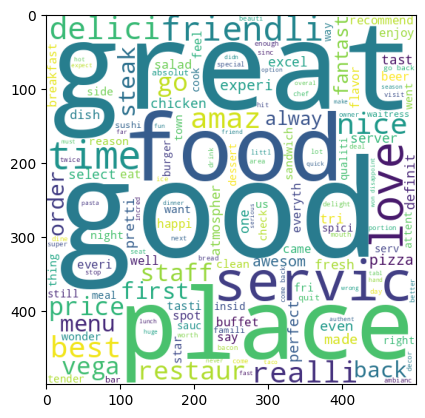

In [30]:
plt.imshow(pos_reviews)

In [32]:
neg_reviews = wc.generate(data[data['Liked'] == 0]['processed_text'].str.cat(sep=" "))

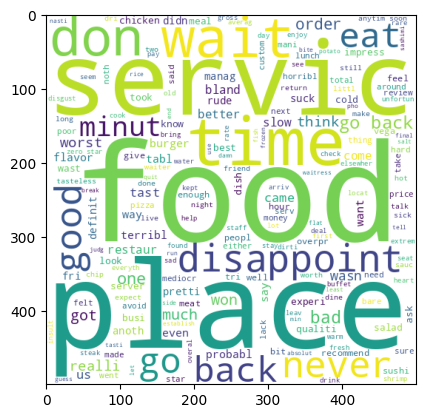

In [33]:
plt.imshow(neg_reviews)

# 3. Feature Engineering 

In [35]:
cv=CountVectorizer(max_features=1500)
X=cv.fit_transform(corpus).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [36]:
X.shape

(1000, 1500)

In [37]:
y=data['Liked']

In [38]:
y

0      1
1      0
2      0
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Liked, Length: 1000, dtype: int64

In [41]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [49]:
# Training Naive Bayes Model

nb=GaussianNB()
nb.fit(X_train, y_train)
y_pred=nb.predict(X_test)

In [50]:
accuracy_score(y_test,y_pred)

0.68

In [47]:
# Training Logistic Regression Model
lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pred=lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.79

In [52]:
# Training Random Forest Classifier model
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8

**Conclusion:** From above accuracy results, we conclude that Random Forest Classifier performs best on the data.

In [56]:
import joblib
import shutil
from IPython.display import FileLink

# Save the model
joblib.dump(rf, "Restaurant_review_model.joblib")

# Move to Kaggle's working directory (optional but recommended)
shutil.move("Restaurant_review_model.joblib", "/kaggle/working/Restaurant_review_model.joblib")

'/kaggle/working/Restaurant_review_model.joblib'